# Лекция 6. Динамическое программирование

## Одномерная динамика

У нас есть какая-то система и мы про нее что-то знаем, обозначим ее точкой и далее наращиваем какое-то постоянное знание о системе, в конечном итоге мы сможем прийти к какому-то решению.



Начнем с самой простой задачи про кролика и удава.

У нас есть какая-то лестница, на нижней ступеньке сидит кролик - просто чилловый парень, который может прыгать на 1-2-3 ступеньки, наверху - удав (голодный). Нам интересно узнать количество вариантов "допрыгаться" кролику.

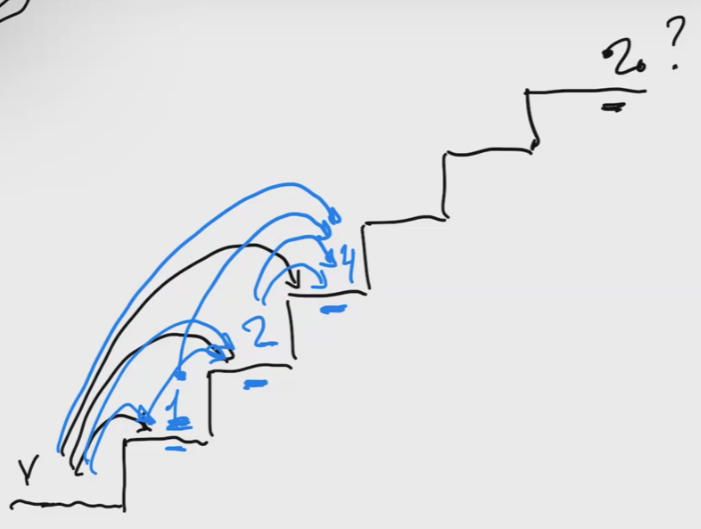

Рассмотрим следующую ступеньку:
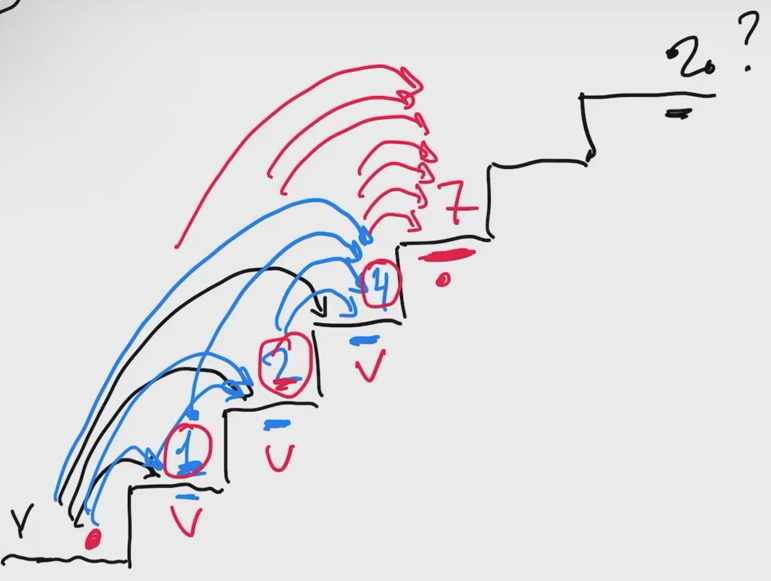

И так далее...
Какая тут будет формула в итоге?

База динамики - это то, что мы выставляем первоначально.

После того как мы задали базу динамики начиная с i-ой позиции можем начать рассчитывать: **dp[i] = dp[i -1] + dp[i - 2] + dp[i- 3]**

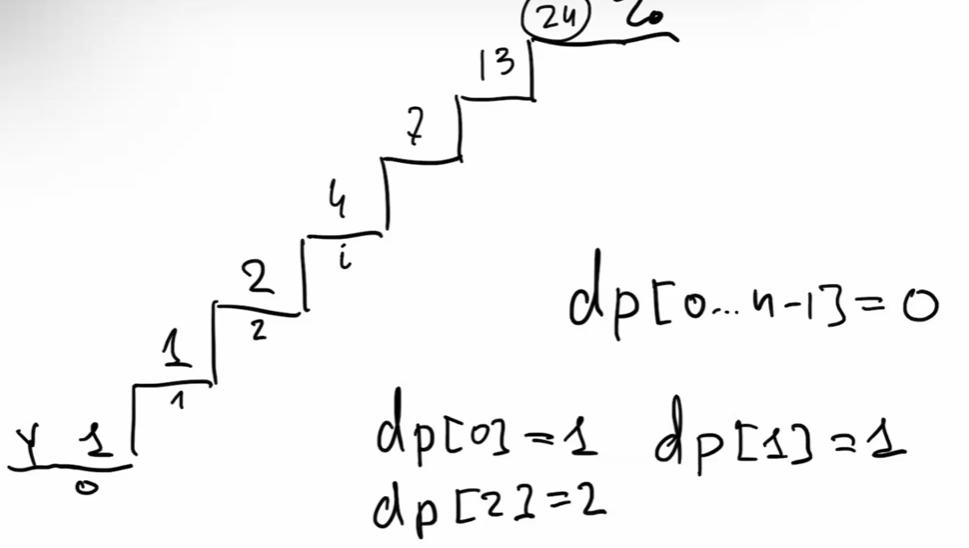

Немного усложним задачу - **платная лестница**.

Теперь каждая ступенька весит сколько-то денег, и мы можем ходить на одну или через одну ступеньку. Наша задача это раазными схэмами достигнуть максимума и заплатить как можно меньше, то есть узнать, какая минимальная сумма понадобится, чтобы добраться до верхней ступеньки.



Хочется начать решать жадно, но эта жадность может подвести - иногда нам лучше потерять, чтобы потом не потерять еще больше:

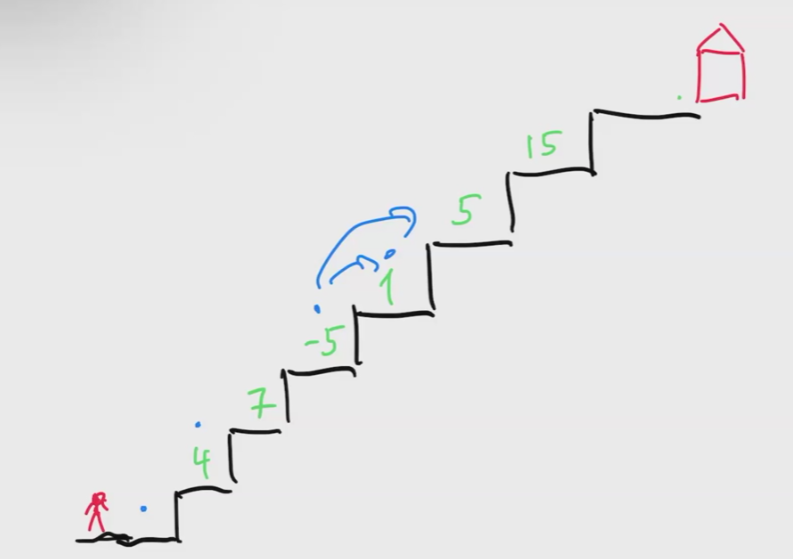


Попав на 1 ступеньку, тратим 4 монетки, на 2 - 7 монеток, минимально потратить, попав на 3 ступеньку, мы можем из 1 или 2 ступеьки, из 4 (монетки) выгоднее - идем из 1 ступеньки и получаем -1, далее на 4 ступеньку мы можем попасть из -1 или 7, очевидно, из -1 (3 ступеньки) выгоднее, то есть попадаем на 4 ступеньку за 0 и так далее... Итоговый ответ 4.

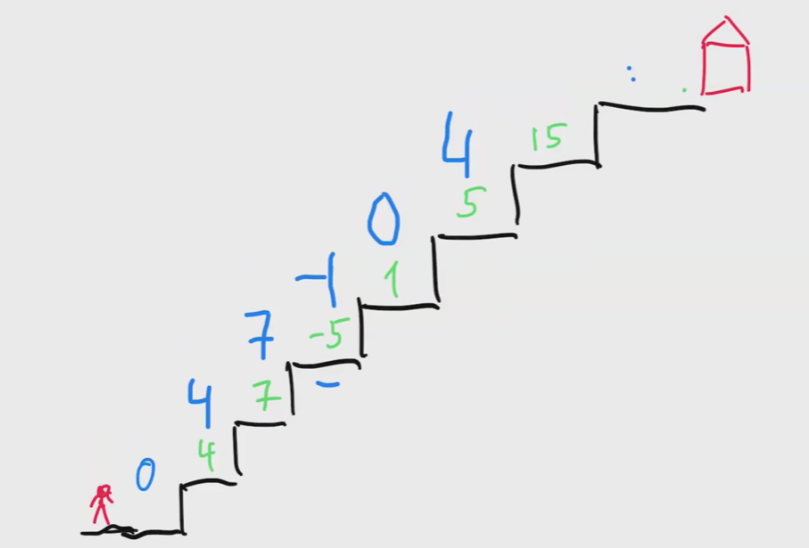




Вводится количество ступенек и их стоимость.

In [3]:
n = int(input())
a = [0] + list(map(int, input().split()))
dp = [0] * 101
dp[0] = 0
dp[1] = a[1]
for i in range(2, n + 1):
  dp[i] = a[i] + min(dp[i - 1], dp[i - 2])
print(dp[n])

5
1 6 2 2 5 2
8


Следующая задача - **взрывоопасность**.

У нас есть стопочка А и стопочка В, мы выстраиваем из них какую-то "историю", допустим АВВА... и так далее. Спрашивается, сколько у нас последовательностей, в которых нет две стопки А подряд.

Скажем, что А - 0, В - 1.

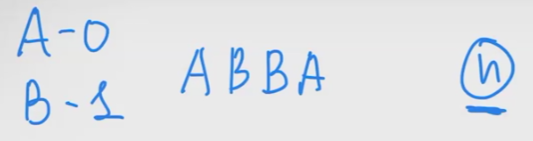

Генерируем все последовательности длины n без двух нулей подряд:

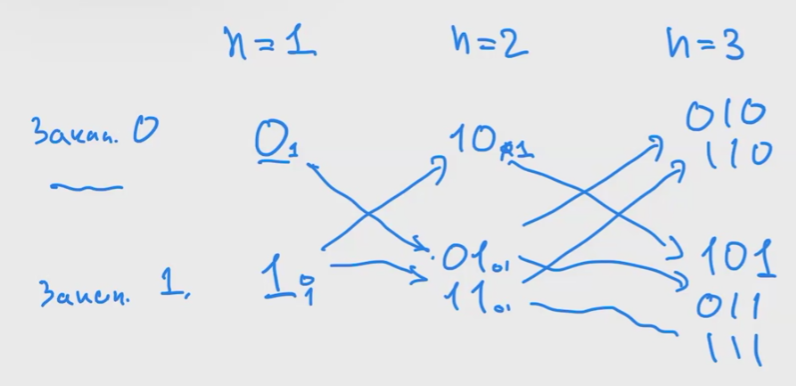

Создадим два массива d_0 и d_1, index - длина, d_0 - количество последовательностей длины i которые заканчиваются на 0 и d_1 - количество последовательностей длины i которые заканчиваются на 1.

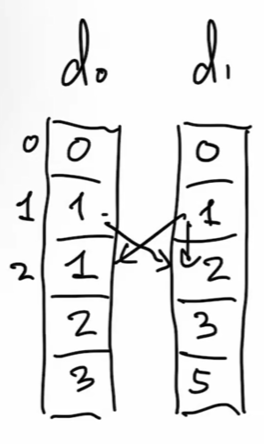


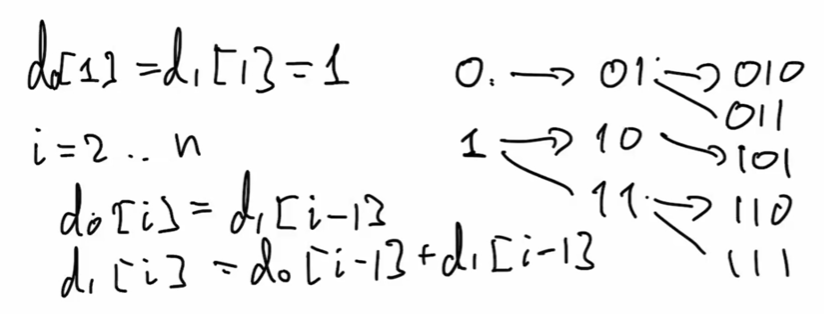



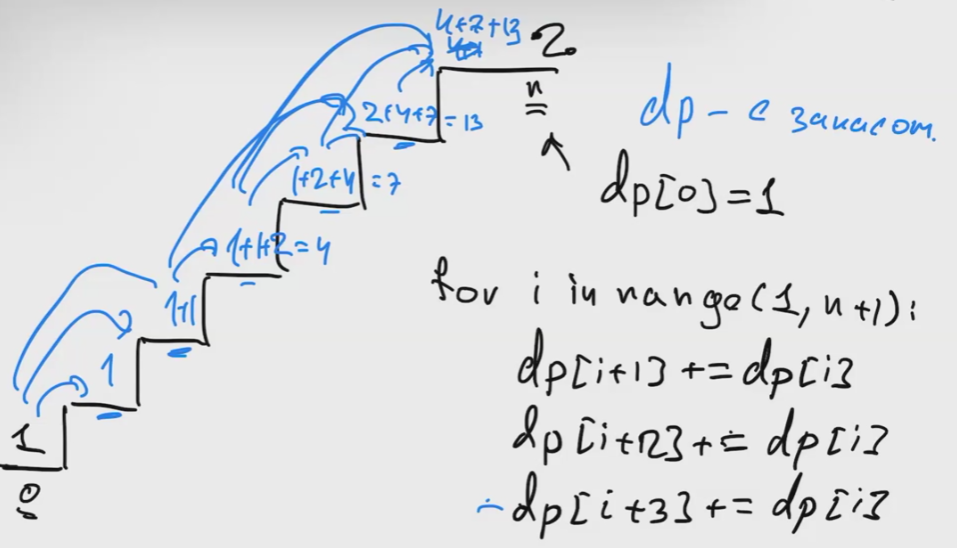

**Анекдот:**
> Молодой человек на конкурс проектов принес машинку для стрижки размером чуть больше головы.

>  Я изобрел уникальную машинку для стрижки! Надеваете ее на голову, и она вас стрижет.

>  Здорово, но у всех же разная голова, всех нужно по-разному подстричь, как она с этим справляется?

>  Ну, да, у всех разная голова, но это до первой стрижки.



Задача - **калькулятор**

У нас такая же лестница, но теперь с i-ой ступеньки мы можем перейти на следующую, улететь на ступеньку 2 * i или на 3 * i. Нужно из единицы получить како-то число n и найти минимальное количество операций.

Например, нам нужно из 1 получить 13 за минимальное число шагов:

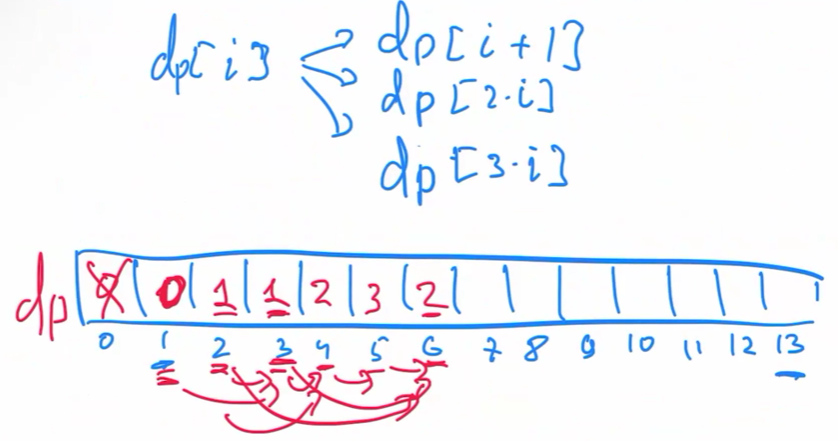

*список предков*

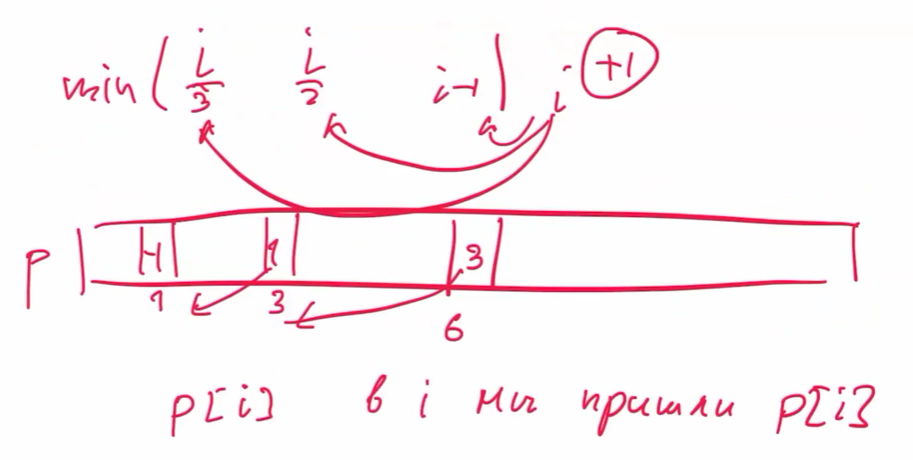

In [4]:
n = int(input())
dp = [0] * (n + 1)
p = [-1] * (n + 1)

# p[i] - список предков, запоминаю откуда пришел
for i in range(2, n +1):
  dp[i] = dp[i - 1] + 1
  p[i] = i - 1
  if i % 2 == 0 and dp[i] > dp[i // 2] + 1:
    dp[i] = dp[i // 2] + 1
    p[i] = i // 2
  if i % 3 == 0 and dp[i] > dp[i // 3] + 1:
    dp[i] = dp[i // 3] + 1
    p[i] = i // 3

print(dp)
print(p)

13
[0, 0, 1, 1, 2, 3, 2, 3, 3, 2, 3, 4, 3, 4]
[-1, -1, 1, 1, 3, 4, 3, 6, 4, 3, 9, 10, 6, 12]


Список предков нужен для востановления ответа:

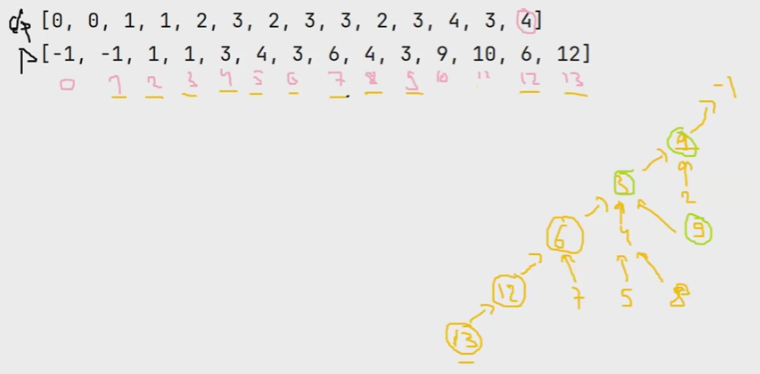

In [5]:
n = int(input())
dp = [0] * (n + 1)
p = [-1] * (n + 1)

# p[i] - список предков, запоминаю откуда пришел
for i in range(2, n +1):
  dp[i] = dp[i - 1] + 1
  p[i] = i - 1
  if i % 2 == 0 and dp[i] > dp[i // 2] + 1:
    dp[i] = dp[i // 2] + 1
    p[i] = i // 2
  if i % 3 == 0 and dp[i] > dp[i // 3] + 1:
    dp[i] = dp[i // 3] + 1
    p[i] = i // 3

v = n
ans = []
while v != -1:
  ans.append(v)
  v = p[v]
print(dp[n])
print(*ans[::-1])

13
4
1 3 6 12 13
